# Implementing Continuous LSTM and Continuous PNN in CapyMOA

Student: **Devis Nishku**

Course: **Streaming Data Analytics 2025/26 - Politecnico di Milano**

This notebook demonstrates the integration of the **cLSTM** and **cPNN** as CapyMOA classifiers and evaluated them against the Weather data stream with prequential (test-then-train) evaluation.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tqdm.notebook import tqdm

sys.path.insert(0, '.')

from capymoa.stream import NumpyStream
from capymoa.evaluation import ClassificationWindowedEvaluator

from clstm import cLSTM
from cpnn import cPNN

The **Weather** stream contains 4 already standardized meteorological features:
* relative humidity RH
* dew point temperature T_d
* wind speed w_s
* wind direction w_d

Binary labels are engineered from air temperature using 5 binary classification functions F1, ..., F5 producing 10 possible concepts. Each configuration uses 8 concepts from this pool, concatenating data from two stations (~4 concepts each).

Concept drifts are **real** and **abrupt**.

In [2]:
weather_df = pd.read_csv('data/weather_1conf_train(in).csv', encoding='utf-8-sig')

FEATURE_COLS = ['RH', 'T_d', 'w_s', 'w_d']
X = weather_df[FEATURE_COLS].to_numpy(dtype=np.float64)
y = weather_df['target'].to_numpy(dtype=np.int32)
task = weather_df['task'].to_numpy(dtype=np.int32)

# Getting first sample index of each new concept (drift positions)
drift_indices = np.where(np.diff(task) != 0)[0] + 1

stream = NumpyStream(
    X=X,
    y=y,
    dataset_name='Weather',
    feature_names=FEATURE_COLS,
    target_name='target',
    target_type='categorical'
)

schema = stream.get_schema()
n_features = schema.get_num_attributes()
n_classes = schema.get_num_classes()


print(f'Shape:                  {weather_df.shape}')
print(f'Features:               {n_features}')
print(f'Classes:                {n_classes}')
print(f'Concepts:               {np.unique(task)}')
print(f'Drifts at indices:      {drift_indices}')
print(f'~Samples per concept:   {len(X) // len(np.unique(task)):,}')

Shape:                  (176844, 6)
Features:               4
Classes:                2
Concepts:               [1 2 3 4 5 6 7 8]
Drifts at indices:      [ 22095  44200  66305  88412 110520 132628 154736]
~Samples per concept:   22,105


## Models

Both models use the following hyperparameters:

| Param | Value |
| --- | --- |
| Window size W | 11 |
| Mini-batch size B | 128 |
| Epochs per batch E | 10 |
| LSTM hidden size H | 50 |
| Learning rate | 0.01 |

* **cLSTM** is a single-column baseline
* **cPNN** is a multi-column ensemble based on the cLSTM 

In [3]:
WINDOW_SIZE = 1000 # evaluation window for windowed Cohen Kappa

clstm_model = cLSTM(schema=schema)
cpnn_model = cPNN(schema=schema)

eval_clstm = ClassificationWindowedEvaluator(schema=schema, window_size=WINDOW_SIZE)
eval_cpnn = ClassificationWindowedEvaluator(schema=schema, window_size=WINDOW_SIZE)

print(clstm_model)
print(cpnn_model)

cLSTMLinear(
  (lstm): LSTM(4, 50, batch_first=True)
  (linear): Linear(in_features=50, out_features=2, bias=True)
)
cPNN with 1 columns, W=11, B=128, E=10, hidden=50, lr=0.01
  Column 0:
    cLSTMLinear(
      (lstm): LSTM(4, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )


## Prequential evaluation (test-then-train loop)

For each instance at time *t*:
1. Predict ŷ_t with both models
2. Evaluate ŷ_t against y_t
3. Drift check: if `task[t] != task[t-1]` then call `cpnn_model.add_new_column()`
4. Train both model on the pair (X_t, y_t)

In [4]:
prev_task = task[0]

for i in tqdm(range(len(X)), desc='Prequential evaluation'):
    instance = stream.next_instance()

    # Predict
    pred_clstm = clstm_model.predict(instance)
    pred_cpnn = cpnn_model.predict(instance)

    # Evaluate
    eval_clstm.update(instance.y_index, pred_clstm)
    eval_cpnn.update(instance.y_index, pred_cpnn)

    # Concept drift check using task labels
    if task[i] != prev_task:
        cpnn_model.add_new_column()
        prev_task = task[i]

    # Train
    clstm_model.train(instance)
    cpnn_model.train(instance)

print(f'Final cPNN configuration:\n')
print(cpnn_model)

Prequential evaluation:   0%|          | 0/176844 [00:00<?, ?it/s]

Final cPNN configuration:

cPNN with 8 columns, W=11, B=128, E=10, hidden=50, lr=0.01
  Column 0:
    cLSTMLinear(
      (lstm): LSTM(4, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )
  Column 1:
    cLSTMLinear(
      (lstm): LSTM(54, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )
  Column 2:
    cLSTMLinear(
      (lstm): LSTM(54, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )
  Column 3:
    cLSTMLinear(
      (lstm): LSTM(54, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )
  Column 4:
    cLSTMLinear(
      (lstm): LSTM(54, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )
  Column 5:
    cLSTMLinear(
      (lstm): LSTM(54, 50, batch_first=True)
      (linear): Linear(in_features=50, out_features=2, bias=True)
    )
  Column 6:
    cLSTMLinear(
      (lst

## Plotting the results (Cohen Kappa)

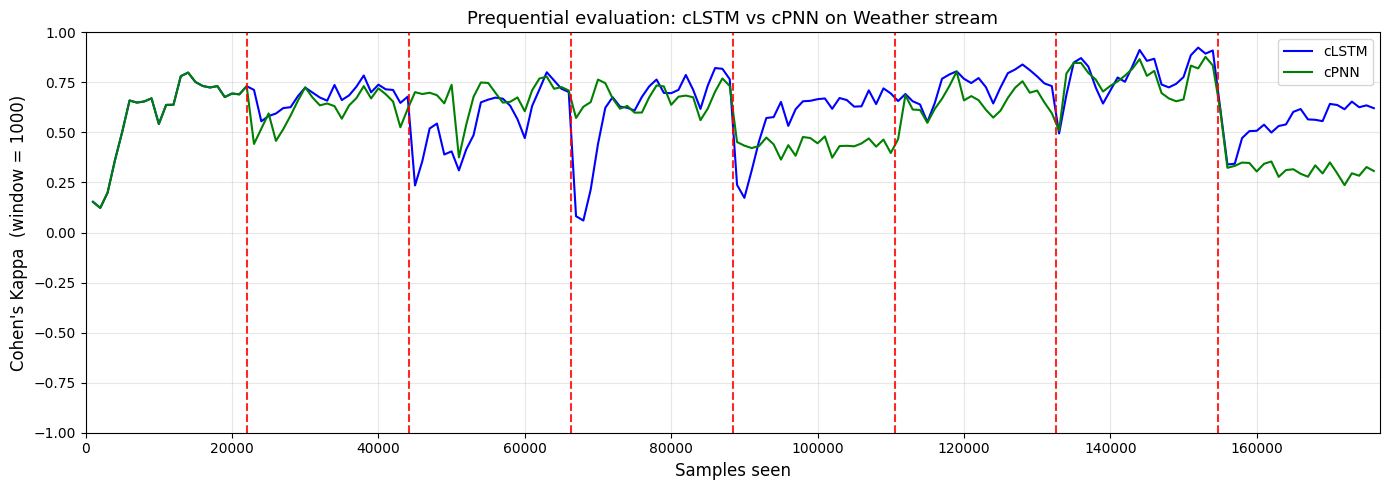

In [15]:
k_clstm = np.array(eval_clstm.kappa()) / 100
k_cpnn  = np.array(eval_cpnn.kappa()) / 100

n_windows = len(k_clstm)
x_axis = np.arange(1, n_windows + 1) * WINDOW_SIZE

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(x_axis, k_clstm, label='cLSTM', color='blue', linewidth=1.5)
ax.plot(x_axis, k_cpnn, label='cPNN', color='green', linewidth=1.5)

for idx in drift_indices:
    ax.axvline(x=idx, color='red', linestyle='--', linewidth=1.5, alpha=0.85)

ax.set_xlim(0, len(X))
ax.set_ylim(-1.0, 1.0)

ax.set_xlabel("Samples seen", fontsize=12)
ax.set_ylabel(f"Cohen's Kappa  (window = {WINDOW_SIZE})", fontsize=12)
ax.set_title("Prequential evaluation: cLSTM vs cPNN on Weather stream", fontsize=13)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
bounds = np.concatenate([[0], drift_indices, [len(X)]])
bounds_w = bounds // WINDOW_SIZE

rows = []
for c in range(len(bounds) - 1):
    lo, hi = int(bounds_w[c]), int(bounds_w[c + 1])

    if hi <= lo:
        continue

    kc = k_clstm[lo:hi]
    kp = k_cpnn[lo:hi]
    avg_kc, avg_kp = float(np.mean(kc)), float(np.mean(kp))

    rows.append({
        "Concept": c + 1,
        "Samples": f"{int(bounds[c])} - {int(bounds[c+1])}",
        "cLSTM avg": round(avg_kc, 3),
        "cLSTM min": round(float(np.min(kc)), 3),
        "cLSTM max": round(float(np.max(kc)), 3),
        "cLSTM std": round(float(np.std(kc)), 3),
        "cPNN avg": round(avg_kp, 3),
        "cPNN min": round(float(np.min(kp)), 3),
        "cPNN max": round(float(np.max(kp)), 3),
        "cPNN std": round(float(np.std(kp)), 3),
        "Delta-k (cPNN - cLSTM)": round(avg_kp - avg_kc, 3)
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

 Concept         Samples  cLSTM avg  cLSTM min  cLSTM max  cLSTM std  cPNN avg  cPNN min  cPNN max  cPNN std  Delta-k (cPNN - cLSTM)
       1       0 - 22095      0.596      0.123      0.799      0.198     0.596     0.123     0.799     0.198                   0.000
       2   22095 - 44200      0.678      0.556      0.784      0.055     0.617     0.442     0.731     0.080                  -0.061
       3   44200 - 66305      0.560      0.235      0.801      0.154     0.679     0.375     0.779     0.085                   0.119
       4   66305 - 88412      0.613      0.060      0.822      0.214     0.667     0.561     0.770     0.060                   0.054
       5  88412 - 110520      0.580      0.173      0.720      0.148     0.436     0.364     0.480     0.032                  -0.144
       6 110520 - 132628      0.732      0.552      0.839      0.072     0.652     0.466     0.804     0.072                  -0.080
       7 132628 - 154736      0.791      0.495      0.924      0.102 

## Comments on the observable results

* Since the cPNN is composed of a single cLSTM column, the first concept is tackled in the same way in both architectures so performances are equal.
* Immediately after each concept drift the results show that the cLSTM model suffers from bigger **performance drops** on the new concept than the cPNN model.
* The cPNN model shows more **stable** performances within the same concept: as new samples from the same concept arrive the performance does *not fluctuate* much from the average in that concept.
* The cLSTM model outperforms the cPNN model in the current concept after enough samples have been received and used for training.

This is a result of the fact that in cPNN, even though only the last (active) column is trained on the new concept, at inference time the output of the active column depends also on the knowledge embedded into the weights of the "old" columns that preserve previous concepts. Meanwhile, the cLSTM is trained as a whole on the new concept. 

Intuitively, after enough samples have been received by each model the cLSTM can be re-trained entirely on the new concept, so at inference time the predictions will be more accurate for the current concept, at the expense of worse performance on previous concepts. On the other hand, the cPNN can only fit the new concept through the *active column*, whose input is augmented with the lateral hidden state coming from the *frozen columns*: part of the capacity of the active column must be spent reconciling this fixed lateral signal with the current concept, rather than just fitting new samples.

In other words, the behavior highlighted from the observed results is that the models trade plasticity for stability on the concepts learned so far.
* **cLSTM** behaves like a *plastic* learner, potentially overwriting previous knowledge to specialize on the current concept.
* **cPNN** behaves like a *stable* learner, preserving the knowledge in frozen columns and exploiting it via the lateral connections.

On the Weather stream the drifts are **abrupt and contradictory**: from one sample to the next, the labelling rule changes instantaneously and the new rule may even invert the labels of the previous one. This sharply amplifies the trade-off described above.

For the **cLSTM**, an abrupt and contradictory drift means that the weights that produced correct predictions on the previous concept now produce systematically wrong ones: the post-drift dip is very deep, because the model has to actively *un-learn* the previous concept before it can adapt to the new one.

For the **cPNN**, the same drift means that the lateral hidden state coming from the (frozen) previous column is now *anti-correlated* with the new target: the active column does not just have to learn the new concept, it has to learn it *while compensating* for a fixed lateral signal that pushes it in the wrong direction. This is why the post-drift dip is shallower (the new column starts fresh and is initially neutral) but the long-run plateau on the new concept stays lower than what cLSTM can reach by re-fitting all of its weights from scratch.